#### **Quando os juros sobem, a inadimplência sobe? (análise com controles)**

Esta é a versão 2 do estudo. A versão 1 comparou diretamente a taxa de juros de
crédito livre referencial (SGS 432) com a inadimplência de pessoas físicas
(SGS 21084). Aqui damos dois passos adicionais:

1. **Controles macroeconômicos**: acrescentamos o IPCA mensal (SGS 433) e o
   endividamento das famílias (SGS 29037), que competem com os juros na
   explicação da inadimplência.
2. **Correção da base estatística**: reavaliamos a ordem de integração com mais
   testes e tratamos a cointegração explicitamente, em vez de ignorá-la.

A pergunta continua a mesma; o que muda é o quanto seguramos as outras coisas
constantes.

#### **Preparando a bancada de análise**

Importamos as ferramentas de dados, gráficos, testes de raiz unitária e
cointegração, além das funções do projeto: o teste de Toda–Yamamoto
(`src/toda_yamamoto.py`) e as projeções locais (`src/local_projections.py`).

In [1]:
import sys
sys.path.append('../src')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen, select_coint_rank, VECM
from arch.unitroot import ZivotAndrews

from toda_yamamoto import toda_yamamoto_causality
from local_projections import local_projection, resultados_para_dataframe

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

#### **1. Carregamento dos dados**

Lemos o CSV consolidado pelo script de coleta. Ele já alinha as quatro séries por
mês, sem interpolar inadimplência.

In [2]:
df = pd.read_csv('../data/processed/dataset_consolidado.csv', parse_dates=['data'])
df = df.set_index('data').sort_index()

series = ['taxa_juros', 'inadimplencia_pf', 'ipca', 'endividamento_familias']
print(f"Período: {df.index.min():%Y-%m} a {df.index.max():%Y-%m} | {len(df)} observações mensais")
print('Valores ausentes:', int(df.isna().sum().sum()))
df.head()

Período: 2011-03 a 2026-06 | 184 observações mensais
Valores ausentes: 0


,taxa_juros,inadimplencia_pf,ipca,endividamento_familias
data,,,,
2011-03-01,11.7177,4.6200,0.7900,34.8600
2011-04-01,11.8000,4.6700,0.7700,34.9000
2011-05-01,12.0000,4.8200,0.4700,35.1100
2011-06-01,12.1833,4.7900,0.1500,35.2900
2011-07-01,12.3387,4.9000,0.1600,35.3700


Conferimos, então, as distribuições e a correlação nos níveis e nas primeiras
diferenças. A correlação em nível pode ser inflada por tendências comuns; a das
diferenças olha para mudanças de um mês para o outro.

In [3]:
print(df[series].describe().T[['count', 'mean', 'std', 'min', 'max']])
print('\nCorrelação (níveis):')
print(df[series].corr())
print('\nCorrelação (primeira diferença):')
print(df[series].diff().dropna().corr())

                          count    mean    std     min     max
taxa_juros             184.0000 10.0562 3.7284  2.0000 15.0000
inadimplencia_pf       184.0000  4.0804 0.6754  2.8900  5.6200
ipca                   184.0000  0.4674 0.3609 -0.6800  1.6200
endividamento_familias 184.0000 42.0582 4.9261 34.8600 49.9200

Correlação (níveis):
                        taxa_juros  inadimplencia_pf    ipca  \
taxa_juros                  1.0000            0.4686 -0.0100   
inadimplencia_pf            0.4686            1.0000 -0.1301   
ipca                       -0.0100           -0.1301  1.0000   
endividamento_familias      0.3354           -0.1478  0.0366   

                        endividamento_familias  
taxa_juros                              0.3354  
inadimplencia_pf                       -0.1478  
ipca                                    0.0366  
endividamento_familias                  1.0000  

Correlação (primeira diferença):
                        taxa_juros  inadimplencia_pf    ipca  \

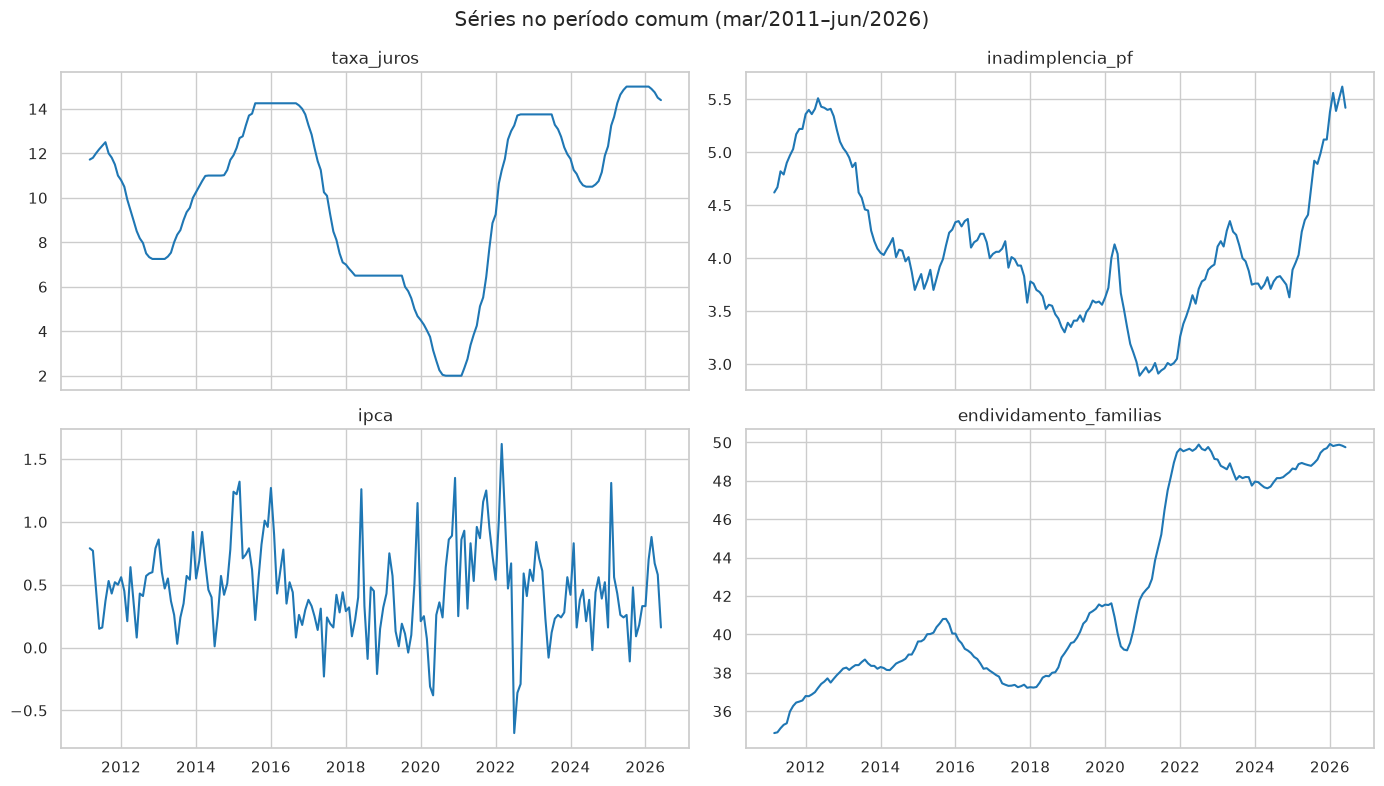

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, coluna in zip(axes.ravel(), series):
    ax.plot(df.index, df[coluna], color='tab:blue')
    ax.set_title(coluna)
fig.suptitle('Séries no período comum (mar/2011–jun/2026)')
plt.tight_layout()
plt.show()

#### **2. As séries são estacionárias?**

Usamos três testes. O ADF parte da hipótese nula de raiz unitária; o KPSS, da
hipótese nula de estacionariedade. Os dois juntos reduzem o risco de um rótulo
errado. O Zivot–Andrews é um ADF que permite uma quebra estrutural — relevante por
causa da pandemia de 2020.

In [5]:
def resumo_estacionariedade(serie, nome):
    serie = serie.dropna()
    return {
        'série': nome,
        'ADF p (nível)': adfuller(serie, autolag='AIC')[1],
        'KPSS p (nível)': kpss(serie, regression='c', nlags='auto')[1],
        'Zivot–Andrews p (nível)': ZivotAndrews(serie).pvalue,
        'ADF p (1ª dif.)': adfuller(serie.diff().dropna(), autolag='AIC')[1],
        'KPSS p (1ª dif.)': kpss(serie.diff().dropna(), regression='c', nlags='auto')[1],
    }

diagnostico = pd.DataFrame(
    [resumo_estacionariedade(df[c], c) for c in series]
).set_index('série')
diagnostico

/tmp/ipykernel_27177/2686851933.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  'KPSS p (nível)': kpss(serie, regression='c', nlags='auto')[1],
/tmp/ipykernel_27177/2686851933.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  'KPSS p (1ª dif.)': kpss(serie.diff().dropna(), regression='c', nlags='auto')[1],
/tmp/ipykernel_27177/2686851933.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  'KPSS p (1ª dif.)': kpss(serie.diff().dropna(), regression='c', nlags='auto')[1],
/tmp/ipykernel_27177/2686851933.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The act

,ADF p (nível),KPSS p (nível),Zivot–Andrews p (nível),ADF p (1ª dif.),KPSS p (1ª dif.)
série,,,,,
taxa_juros,0.4652,0.1000,0.7762,0.0003,0.1000
inadimplencia_pf,0.1867,0.0309,0.8545,0.0152,0.1000
ipca,0.0000,0.1000,0.0000,0.0000,0.1000
endividamento_familias,0.7831,0.0100,0.0144,0.0003,0.1000


Leitura dos resultados:

- **taxa_juros**: não estacionária no nível, estacionária na primeira diferença →
  tratada como **I(1)**.
- **inadimplencia_pf**: o ADF rejeita a raiz unitária na primeira diferença
  (agora com clareza, ao contrário do resultado limítrofe da v1) → **I(1)**.
- **ipca**: estacionária já no nível → **I(0)**.
- **endividamento_familias**: ADF e KPSS apontam tendência, mas o Zivot–Andrews
  rejeita a raiz unitária quando se permite uma quebra. Como a evidência é mista,
  tratamos com prudência como **I(1)**.

Com isso, a maior ordem de integração considerada é **dmax = 1**, e não 2 como na
v1. Isso importa: um `dmax` grande demais acrescenta defasagens, consome graus de
liberdade e reduz a potência dos testes.

#### **3. Quantas defasagens — e quanto isso custa?**

Comparamos os critérios de informação nos níveis e nas primeiras diferenças. A
seguir contamos quantos parâmetros o sistema estima, para deixar explícito o
trade-off entre dinâmica e graus de liberdade.

In [6]:
selecao_niveis = VAR(df[series]).select_order(maxlags=8)
selecao_dif = VAR(df[series].diff().dropna()).select_order(maxlags=8)
print('Níveis     ->', {k: getattr(selecao_niveis, k) for k in ['aic', 'bic', 'hqic', 'fpe']})
print('Diferenças ->', {k: getattr(selecao_dif, k) for k in ['aic', 'bic', 'hqic', 'fpe']})

k = selecao_dif.aic
print('\nk escolhido pelo AIC (diferenças):', k)

Níveis     -> {'aic': np.int64(7), 'bic': np.int64(2), 'hqic': np.int64(4), 'fpe': np.int64(7)}
Diferenças -> {'aic': np.int64(6), 'bic': np.int64(1), 'hqic': np.int64(3), 'fpe': np.int64(6)}

k escolhido pelo AIC (diferenças): 6


/mnt/vms/PORTFOLIO/preditores_de_inadimplencia/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/mnt/vms/PORTFOLIO/preditores_de_inadimplencia/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [7]:
n_var = len(series)
params_por_eq = n_var * k + 1
print(f'Parâmetros por equação: {params_por_eq}')
print(f'Parâmetros no sistema inteiro: {params_por_eq * n_var}')
print(f'Observações efetivas para o VAR: ~{len(df) - k}')

Parâmetros por equação: 25
Parâmetros no sistema inteiro: 100
Observações efetivas para o VAR: ~178


O VAR de 4 variáveis com 6 defasagens estima 100 parâmetros em um sistema com
menos de 180 observações efetivas. É viável, mas deixa claro por que adicionar
variáveis não é gratuito: cada série nova aumenta o número de coeficientes de
forma quadrática.

#### **4. Existe uma relação de longo prazo? (cointegração)**

O teste de Johansen procura combinações estáveis entre séries com tendência. Se
existir cointegração, um VECM descreve tanto os ajustes de curto prazo quanto o
retorno ao equilíbrio de longo prazo — e é mais adequado do que um VAR nas
diferenças puro.

In [8]:
johansen = coint_johansen(df[series], det_order=0, k_ar_diff=k)
tabela_johansen = pd.DataFrame({
    'H0': [f'r <= {i}' for i in range(len(johansen.lr1))],
    'estatística do traço': johansen.lr1,
    'cv 90%': johansen.cvt[:, 0],
    'cv 95%': johansen.cvt[:, 1],
    'cv 99%': johansen.cvt[:, 2],
})
tabela_johansen

,H0,estatística do traço,cv 90%,cv 95%,cv 99%
0,r <= 0,60.6249,44.4929,47.8545,54.6815
1,r <= 1,22.8350,27.0669,29.7961,35.4628
2,r <= 2,8.3889,13.4294,15.4943,19.9349
3,r <= 3,3.5504,2.7055,3.8415,6.6349


In [9]:
rank = select_coint_rank(
    df[series], det_order=0, k_ar_diff=k, method='trace', signif=0.05
).rank
print('Posto de cointegração selecionado a 5%:', rank)

modelo_vecm = VECM(
    df[series], k_ar_diff=k, coint_rank=rank, deterministic='ci'
).fit()

print('\nCoeficientes de carga (alpha): ajuste ao equilíbrio de longo prazo')
print(pd.DataFrame(
    modelo_vecm.alpha, index=series,
    columns=[f'ec{i+1}' for i in range(rank)]
))

Posto de cointegração selecionado a 5%: 1

Coeficientes de carga (alpha): ajuste ao equilíbrio de longo prazo
                           ec1
taxa_juros             -0.0037
inadimplencia_pf        0.0054
ipca                    0.0291
endividamento_familias -0.0074


/mnt/vms/PORTFOLIO/preditores_de_inadimplencia/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [10]:
linhas = []
for causado in series:
    for causador in series:
        if causado == causador:
            continue
        teste = modelo_vecm.test_granger_causality(caused=causado, causing=causador)
        linhas.append({
            'hipótese nula': f'{causador} não causa {causado}',
            'chi2': teste.test_statistic,
            'p_valor': teste.pvalue,
        })
tabela_ecm = pd.DataFrame(linhas)
tabela_ecm

,hipótese nula,chi2,p_valor
0,inadimplencia_pf não causa taxa_juros,1.5946,0.1342
1,ipca não causa taxa_juros,1.4726,0.1743
2,endividamento_familias não causa taxa_juros,1.9950,0.0538
3,taxa_juros não causa inadimplencia_pf,1.7372,0.0978
4,ipca não causa inadimplencia_pf,1.2418,0.2776
5,endividamento_familias não causa inadimplencia_pf,3.0346,0.0038
6,taxa_juros não causa ipca,0.9406,0.4744
7,inadimplencia_pf não causa ipca,2.0330,0.0491
8,endividamento_familias não causa ipca,1.1498,0.3302
9,taxa_juros não causa endividamento_familias,1.8077,0.0833


Há evidência de **uma** relação de cointegração a 5%. O coeficiente de carga da
inadimplência (`ec1`) é positivo e significativo: quando a inadimplência se afasta
do equilíbrio de longo prazo, ela tende a se ajustar de volta. Já a taxa de juros
não exibe esse ajustamento.

No teste de Granger via VECM, a direção juros → inadimplência fica em torno de
p ≈ 0,10 — isto é, **limítrofe**, sem rejeição ao nível de 5%. Vale lembrar que o
teste do VECM captura também o canal de longo prazo.

#### **5. Toda–Yamamoto, agora com `dmax` corrigido**

O Toda–Yamamoto estima um VAR em nível com `k + dmax` defasagens e testa apenas as
primeiras `k`. Ele é válido mesmo quando existe cointegração, desde que `dmax`
seja pelo menos a ordem de integração verdadeira. Com `dmax = 1`, estimamos um
VAR(7); com `dmax = 2`, um VAR(8). Comparamos os dois para mostrar a sensibilidade.

In [11]:
linhas = []
for dmax in (1, 2):
    for causa, efeito in [
        ('taxa_juros', 'inadimplencia_pf'),
        ('inadimplencia_pf', 'taxa_juros'),
    ]:
        resultado = toda_yamamoto_causality(
            df, causa, efeito, selected_lags=k, max_integration_order=dmax
        )
        linhas.append({
            'dmax': dmax,
            'hipótese nula': f'{causa} não causa {efeito}',
            'Wald': resultado.wald_statistic,
            'gl': resultado.degrees_of_freedom,
            'p_valor': resultado.p_value,
            'defasagens estimadas': resultado.estimated_lags,
        })
tabela_ty = pd.DataFrame(linhas)
tabela_ty

,dmax,hipótese nula,Wald,gl,p_valor,defasagens estimadas
0,1,taxa_juros não causa inadimplencia_pf,13.8588,6,0.0313,7
1,1,inadimplencia_pf não causa taxa_juros,4.1438,6,0.6572,7
2,2,taxa_juros não causa inadimplencia_pf,10.7399,6,0.0968,8
3,2,inadimplencia_pf não causa taxa_juros,4.5827,6,0.5983,8


Este é o ponto mais delicado da análise. Com `dmax = 1`, o teste **rejeita** a
hipótese nula juros → inadimplência ao nível de 5% (p ≈ 0,03). Mas com `dmax = 2`
o p-valor sobe para ≈ 0,10 e a rejeição some. A conclusão, portanto, **depende da
ordem de integração adotada**.

Do ponto de vista dos testes de raiz unitária, `dmax = 1` é a escolha defensável.
Ainda assim, a sensibilidade precisa ser reportada, e não escondida. O sentido
inverso (inadimplência → juros) não é significativo em nenhuma das especificações.

#### **6. Projeções locais: a resposta ao longo do tempo, com controles**

As projeções locais (Jordà) estimam uma regressão por horizonte. Isso permite
incluir controles sem inchar um único VAR e desenhar a resposta da inadimplência
com bandas de confiança. Usamos as séries em primeira diferença e padronizamos o
choque: o coeficiente em `h` é a resposta a um choque de **1 desvio-padrão** em
Δjuros.

In [12]:
d = df[series].diff().dropna()

d_pad = d.copy()
d_pad['taxa_juros'] = d_pad['taxa_juros'] / d_pad['taxa_juros'].std()

lp_sem = resultados_para_dataframe(
    local_projection(d_pad, 'inadimplencia_pf', 'taxa_juros', horizons=24, lags=k)
)
lp_com = resultados_para_dataframe(
    local_projection(
        d_pad, 'inadimplencia_pf', 'taxa_juros',
        horizons=24, lags=k, controls=['ipca', 'endividamento_familias']
    )
)

print('Horizontes com p < 0,05 (sem controles):', list(lp_sem[lp_sem.p_valor < 0.05].index))
print('Horizontes com p < 0,05 (com controles):', list(lp_com[lp_com.p_valor < 0.05].index))
lp_com[['coeficiente', 'erro_padrao', 'p_valor']].head(13)

Horizontes com p < 0,05 (sem controles): [2, 3, 9, 10, 11, 13, 14, 15, 24]
Horizontes com p < 0,05 (com controles): [0, 8, 9, 10, 11, 13, 14, 24]


,coeficiente,erro_padrao,p_valor
horizonte,,,
0,-0.0284,0.0140,0.0424
1,-0.0083,0.0115,0.4719
2,0.0186,0.0126,0.1386
3,0.0116,0.0125,0.3524
4,0.0005,0.0176,0.9775
5,0.0195,0.0157,0.2150
6,0.0063,0.0159,0.6918
7,-0.0079,0.0158,0.6193
8,0.0382,0.0180,0.0334


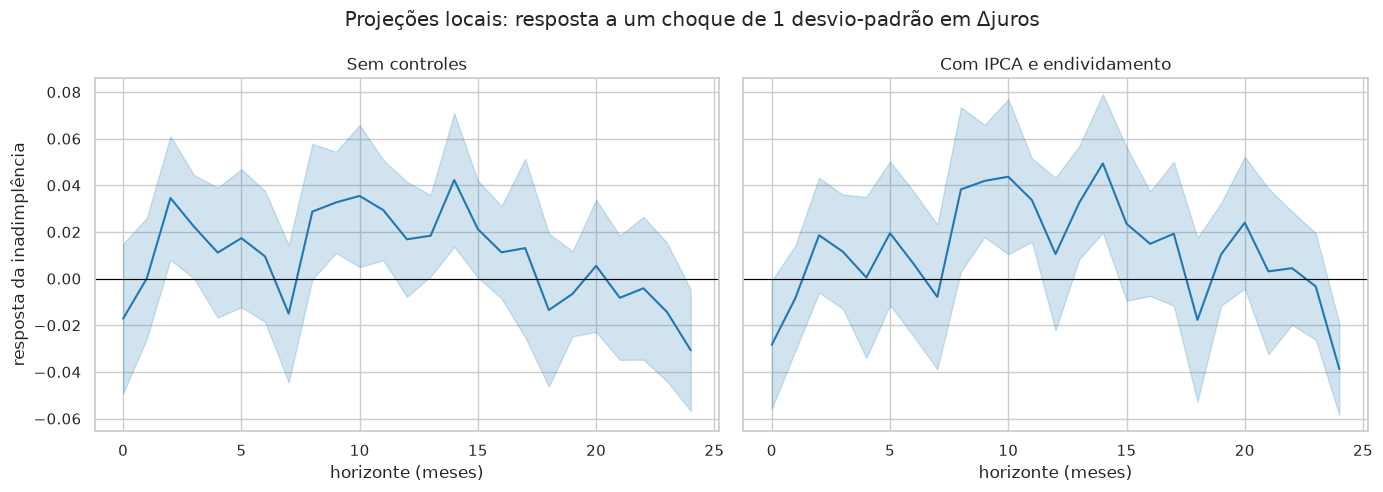

In [13]:
fig, eixos = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for eixo, tabela, titulo in [
    (eixos[0], lp_sem, 'Sem controles'),
    (eixos[1], lp_com, 'Com IPCA e endividamento'),
]:
    eixo.plot(tabela.index, tabela['coeficiente'], color='tab:blue')
    eixo.fill_between(
        tabela.index, tabela['ic_inferior'], tabela['ic_superior'],
        color='tab:blue', alpha=0.2
    )
    eixo.axhline(0, color='black', linewidth=0.8)
    eixo.set_title(titulo)
    eixo.set_xlabel('horizonte (meses)')
eixos[0].set_ylabel('resposta da inadimplência')
fig.suptitle('Projeções locais: resposta a um choque de 1 desvio-padrão em Δjuros')
plt.tight_layout()
plt.show()

A resposta tem um formato de morro: começa perto de zero, fica positiva e
significativa em parte do médio prazo (em torno de 8 a 14 meses com controles) e
depois volta a oscilar. **Cuidado com a leitura**: testamos 25 horizontes, então
alguns p-valores abaixo de 0,05 aparecem por acaso; o interessante é o padrão, não
um ponto isolado. As bandas alargam nos horizontes maiores, como esperado.

#### **7. Robustez: e sem os meses da pandemia?**

A pandemia de 2020 deslocou juros e inadimplência de forma atípica. Reestimamos as
projeções excluindo mar/2020–dez/2021 para ver se o padrão se mantém.

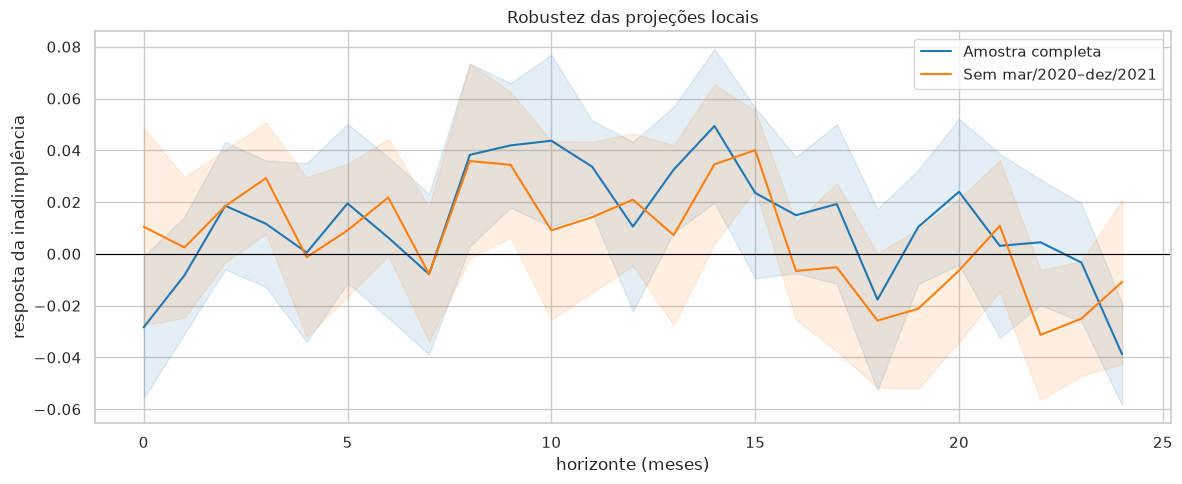

Horizontes com p < 0,05 (sem pandemia): [3, 9, 14, 15, 22, 23]


In [14]:
na_pandemia = (d_pad.index >= '2020-03-01') & (d_pad.index <= '2021-12-01')
d_sem_pandemia = d_pad.loc[~na_pandemia]

lp_robusto = resultados_para_dataframe(
    local_projection(
        d_sem_pandemia, 'inadimplencia_pf', 'taxa_juros',
        horizons=24, lags=k, controls=['ipca', 'endividamento_familias']
    )
)

fig, eixo = plt.subplots(figsize=(12, 5))
for tabela, rotulo, cor in [
    (lp_com, 'Amostra completa', 'tab:blue'),
    (lp_robusto, 'Sem mar/2020–dez/2021', 'tab:orange'),
]:
    eixo.plot(tabela.index, tabela['coeficiente'], label=rotulo, color=cor)
    eixo.fill_between(
        tabela.index, tabela['ic_inferior'], tabela['ic_superior'],
        color=cor, alpha=0.12
    )
eixo.axhline(0, color='black', linewidth=0.8)
eixo.legend()
eixo.set_title('Robustez das projeções locais')
eixo.set_xlabel('horizonte (meses)')
eixo.set_ylabel('resposta da inadimplência')
plt.tight_layout()
plt.show()

print('Horizontes com p < 0,05 (sem pandemia):',
      list(lp_robusto[lp_robusto.p_valor < 0.05].index))

#### **8. O que aprendemos — e o que ainda não sabemos**

Resumo dos achados desta v2, sobre 184 meses (mar/2011–jun/2026):

- Há **uma relação de cointegração** entre as quatro séries, e a inadimplência se
  ajusta a ela. Ignorar isso, como na v1, deixava a especificação incompleta.
- O **Toda–Yamamoto corrigido** (`dmax = 1`) passa a **rejeitar** a não-causalidade
  no sentido juros → inadimplência (p ≈ 0,03); com `dmax = 2`, não rejeita
  (p ≈ 0,10). O resultado é sensível à ordem de integração.
- O **VECM** aponta na mesma direção, mas de forma limítrofe (p ≈ 0,10).
- As **projeções locais** sugerem uma resposta positiva no médio prazo, com
  controles, mas o desenho é de correlação condicional.

Em linguagem direta: ao segurar IPCA e endividamento constantes e corrigir a
especificação, os juros passam a ter **mais** conteúdo preditivo sobre a
inadimplência do que a v1 sugeria. Mas isso continua sendo **precedência preditiva
condicional**, não uma estimativa causal. A sensibilidade a `dmax` mostra que a
evidência ainda não é robusta o suficiente para afirmar um efeito.

#### **Próximas perguntas**

Três caminhos naturais para continuar:

1. **Identificação**: usar restrições de sinal em um VAR estrutural ou variáveis
   instrumentais para separar choques de política monetária de choques de demanda.
2. **Mais controles**: renda, emprego e comprometimento de renda, testando se o
   canal dos juros sobrevive.
3. **Inferência em projeções locais**: corrigir p-valores para múltiplos
   horizontes (por exemplo, bandas por bootstrap) em vez de olhar horizonte a
   horizonte.